In [12]:
import pickle
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots
from neuralhydrology.nh_run import start_run, eval_run

In [15]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP03'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [5]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP03_seqlen_no_sw_10_10basins_2608_144004',
 'EXP03_seqlen_no_sw_270_10basins_2608_145500',
 'EXP03_seqlen_no_sw_30_10basins_2608_144239',
 'EXP03_seqlen_no_sw_60_10basins_2608_144553',
 'EXP03_seqlen_no_sw_90_10basins_2608_144942',
 'EXP03_seqlen_wi_sw_10_10basins_2608_141137',
 'EXP03_seqlen_wi_sw_270_10basins_2608_142822',
 'EXP03_seqlen_wi_sw_30_10basins_2608_141444',
 'EXP03_seqlen_wi_sw_60_10basins_2608_141815',
 'EXP03_seqlen_wi_sw_90_10basins_2608_142239']

In [ ]:
seq10_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_10_10basins_2608_144004',
    fp_wi_sw='EXP03_seqlen_wi_sw_10_10basins_2608_141137',
    run_dir = all_runs_dir)
seq30_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_30_10basins_2608_144239',
    fp_wi_sw='EXP03_seqlen_wi_sw_30_10basins_2608_141444',
    run_dir = all_runs_dir)
seq60_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_60_10basins_2608_144553',
    fp_wi_sw='EXP03_seqlen_wi_sw_60_10basins_2608_141815',
    run_dir = all_runs_dir)
seq90_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_90_10basins_2608_144942',
    fp_wi_sw='EXP03_seqlen_wi_sw_90_10basins_2608_142239',
    run_dir = all_runs_dir)
seq270_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP03_seqlen_no_sw_270_10basins_2608_145500',
    fp_wi_sw='EXP03_seqlen_wi_sw_270_10basins_2608_142822',
    run_dir = all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_wi_sw_10_10basins_2608_141137
# Evaluation:  60%|██████    | 6/10 [00:01<00:00,  4.09it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4150700_toledo_bend.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4152450_glen_canyon.pkl')]
# Evaluation:  80%|████████  | 8/10 [00:02<00:00,  6.21it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/5101500_wivenhoe.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/5608096_ord_river.pkl')]
# Validation: 100%|██████████| 10/10 [00:01<00:00,  6.49it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_wi_sw_10_10basins_2608_141137
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_no_sw_10_10basins_2608_144004
# Evaluation:  30%|███       | 3/10 [00:00<00:01,  5.71it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing

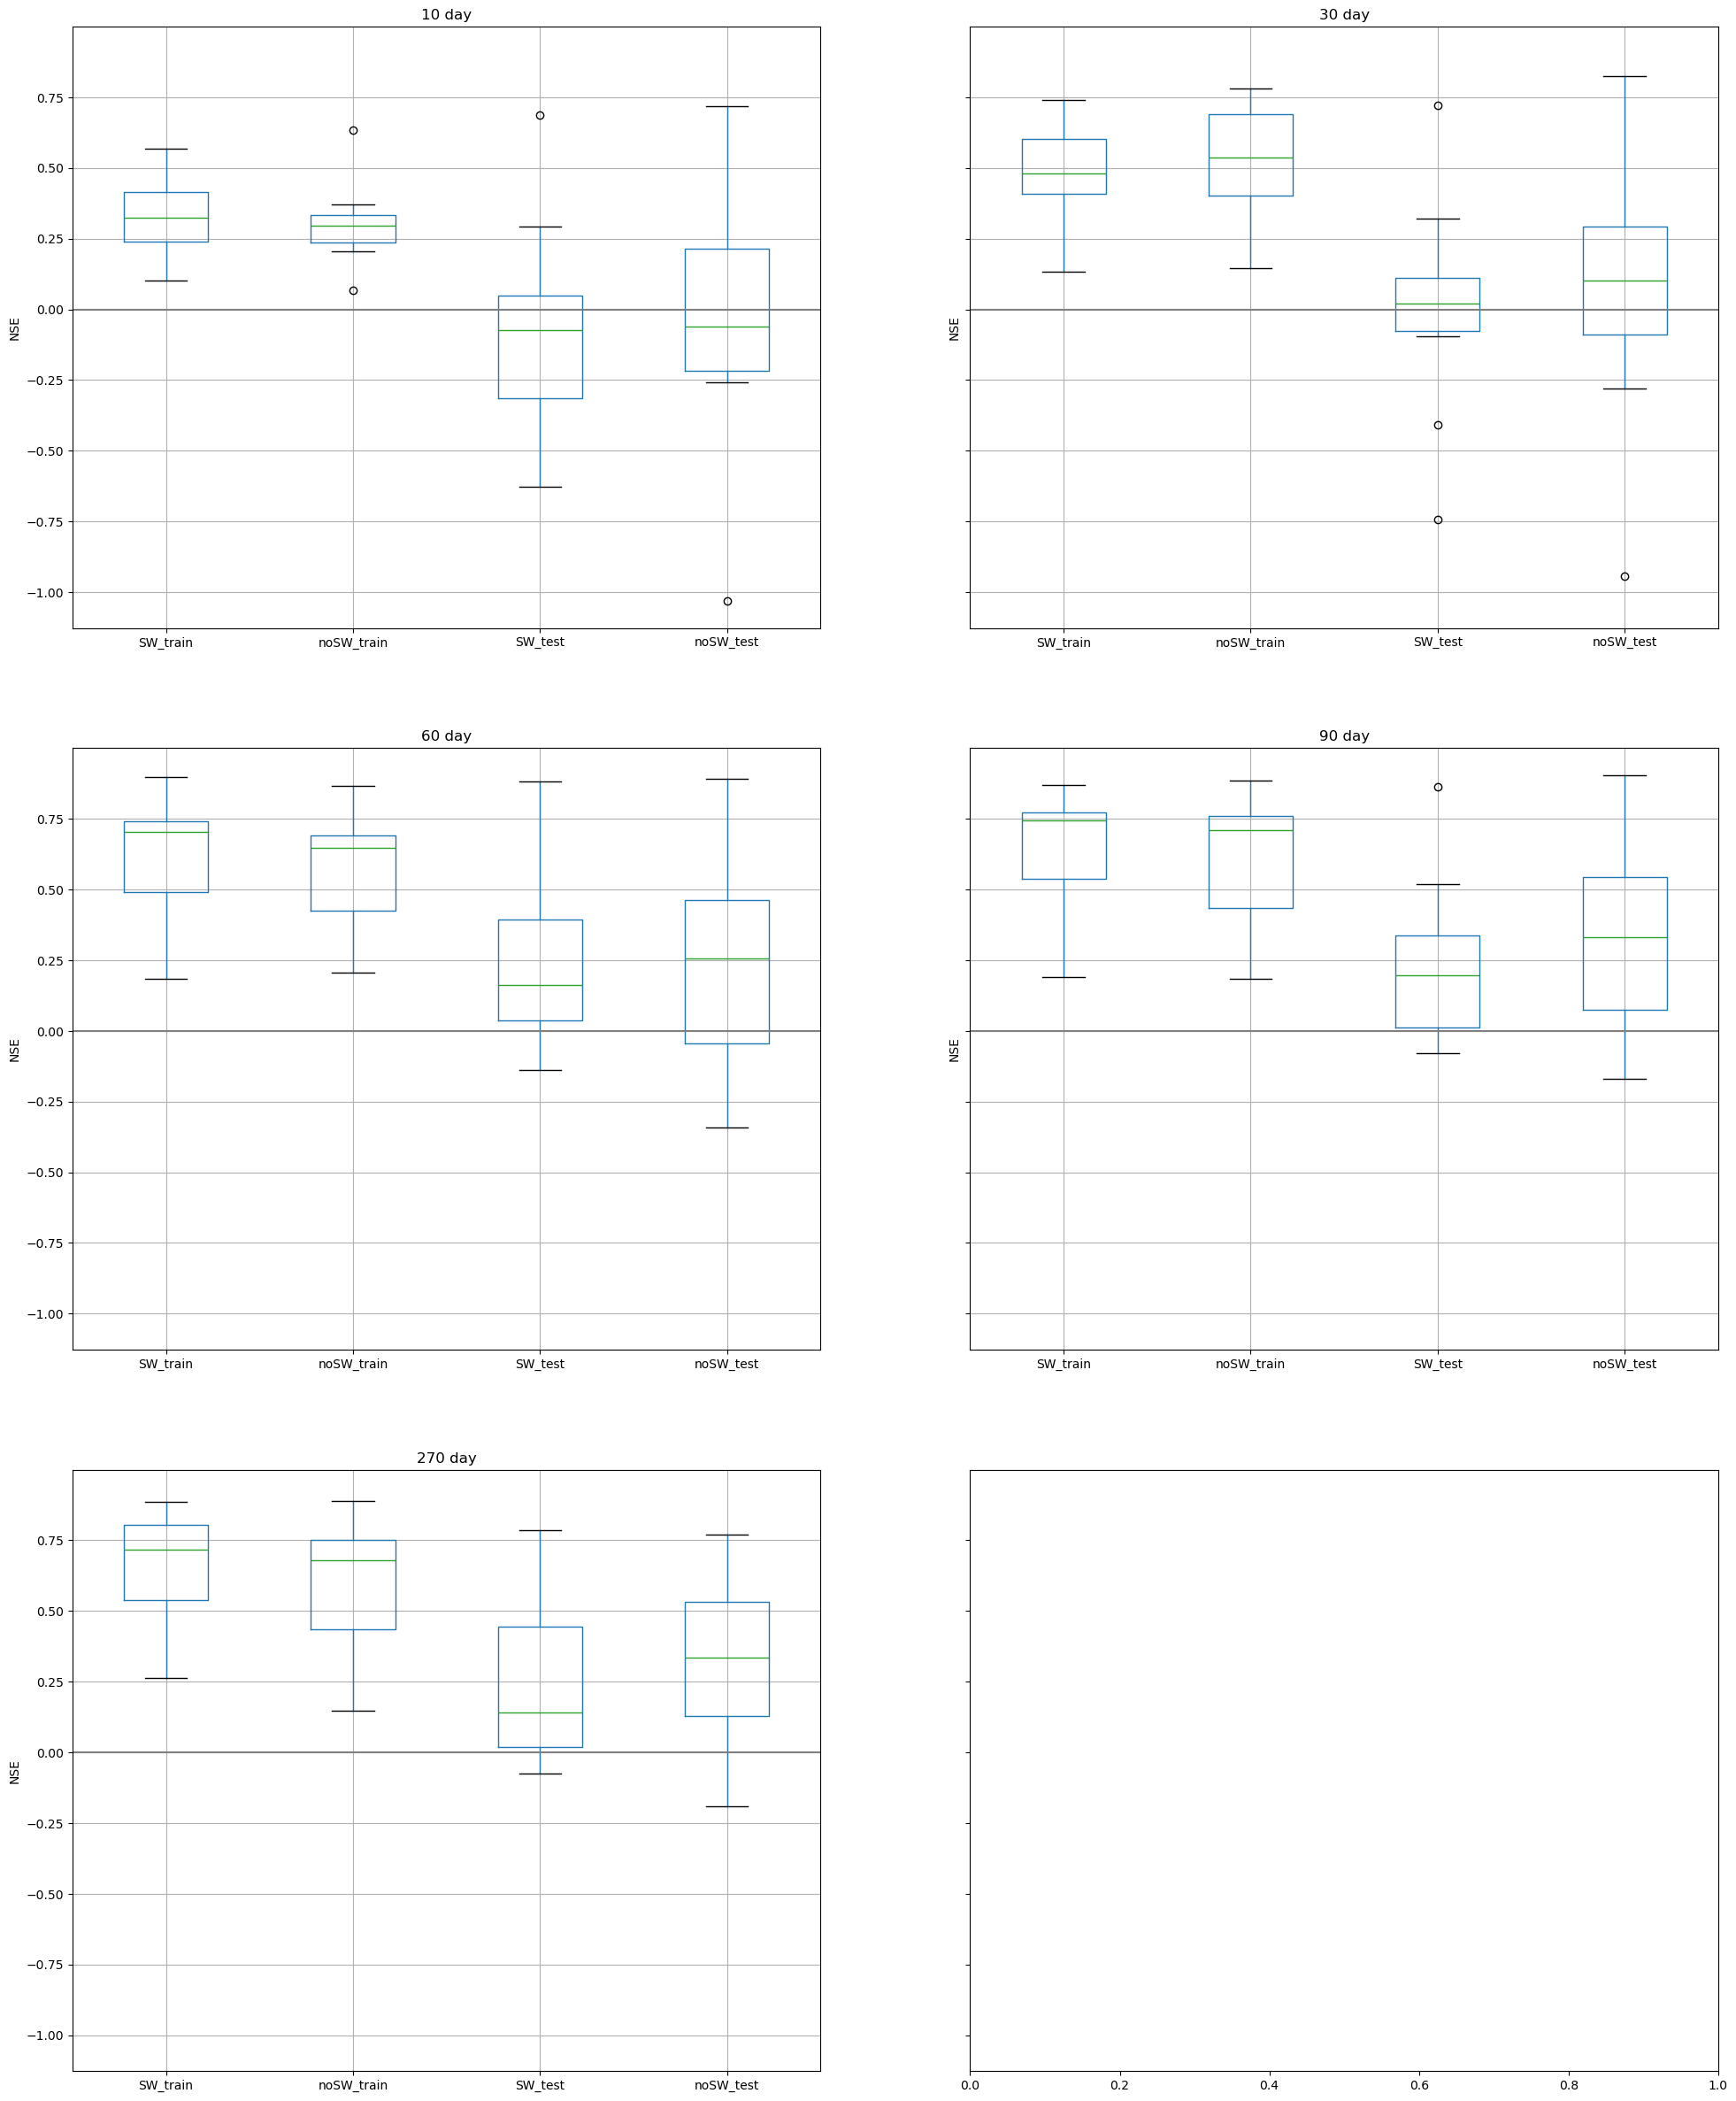

In [18]:
fig, axs = plt.subplots(3, 2, figsize=(24, 30),sharey=True)
seq10_nse_df = comp_plots.boxplot_from_tuple(seq10_metrics,ax=axs[0,0],tuple_names=default_order,exp_name = '10 day')
seq30_nse_df = comp_plots.boxplot_from_tuple(seq30_metrics,ax=axs[0,1],tuple_names=default_order,exp_name = '30 day')
seq60_nse_df = comp_plots.boxplot_from_tuple(seq60_metrics,ax=axs[1,0],tuple_names=default_order,exp_name = '60 day')
seq90_nse_df = comp_plots.boxplot_from_tuple(seq90_metrics,ax=axs[1,1],tuple_names=default_order,exp_name = '90 day')
seq270_nse_df = comp_plots.boxplot_from_tuple(seq270_metrics,ax=axs[2,0],tuple_names=default_order,exp_name = '270 day')